https://github.com/FabricioArendTorres/FlowConductor/tree/main

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os
import numpy as np
import matplotlib.pyplot as plt

from msi.gaussian_mixture.likelihood_gmm import LikelihoodGMM
from msi.gaussian_mixture import architecture
from msi.utils import preprocessing
from msfm.utils import prior, parameters, files, logger

24-02-13 04:35:22   imports.py INF   Setting up healpy to run on 32 CPUs 
24-02-13 04:35:26   imports.py INF   Setting up healpy to run on 32 CPUs 


# load network predictions

### v3

In [3]:
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/config.yaml")
# base_dir = "/pscratch/sd/a/athomsen/run_files/v3"

# # lensing only
# model_dir = "2023-05-29_09-55-49_resnet_vanilla"
# n_steps = 50000
# params = ["Om", "s8", "Aia", "n_Aia"]

### v4

In [4]:
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/config.yaml")
# base_dir = "/pscratch/sd/a/athomsen/run_files/v4"

# # lensing only

# # large_scales (6 Mpc/h)
# model_dir = "2023-08-28_04-29-33_resnet_vanilla"

# n_steps = 50000
# params = ["Om", "s8", "Aia", "n_Aia"]

In [5]:
# # combined probes
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v6/linear_bias.yaml")
# base_dir = "/pscratch/sd/a/athomsen/run_files/v4"

# # all parameters
# model_dir = "2023-08-31_03-29-47_resnet_vanilla"

# n_steps = 20000
# params = ["Om", "s8", "H0", "Ob", "ns", "w0", "Aia", "n_Aia", "bg", "n_bg"]

### v6

#### lensing only

In [6]:
conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v6/linear_bias.yaml")
base_dir = "/pscratch/sd/a/athomsen/run_files/v6/lensing_only"
# base_dir = "/pscratch/sd/a/athomsen/run_files/v6/lensing"

# delta loss
model_dir = "delta/2024-01-12_19-35-59_resnet_vanilla"
# model_dir = "delta/2024-02-06_11-02-57_resnet_vanilla"
# model_dir = "delta/2024-02-08_08-21-34_resnet_vanilla"

# biggest run yet, 100k, 200k and 300k evaluations
# model_dir = "delta/2024-02-09_05-23-03_resnet_vanilla"

# new, smaller run with evaluations every 10k steps (cashed, buggy)
# model_dir = "delta/2024-02-12_00-37-01_resnet_vanilla"

# model_dir = "delta/2024-02-12_06-56-43_resnet_vanilla"

# likelihood loss
# model_dir = "likelihood/2024-01-22_05-29-26_resnet_vanilla"

# new, smaller run with evaluations every 10k steps 
# model_dir = "likelihood/2024-02-12_02-26-58_resnet_vanilla"

n_steps = 290000
params = ["Om", "s8", "w0", "Aia", "n_Aia"]

#### clustering only

#### combined probes

In [7]:
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v6/linear_bias.yaml")
# base_dir = "/pscratch/sd/a/athomsen/run_files/v6/combined"

# # delta loss
# model_dir = "delta/2024-02-02_00-28-48_resnet_vanilla"


# # likelihood loss
# # model_dir = "likelihood/2024-01-30_07-41-40_resnet_vanilla"
# # model_dir = "likelihood/2024-02-01_09-02-59_resnet_vanilla"

# n_steps = 70000
# # params = ["Om", "s8", "H0", "Ob", "ns", "w0", "Aia", "n_Aia", "bg", "n_bg"]
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bg", "n_bg"]

### general

In [8]:
# dataset
fidu_preds, grid_preds, grid_cosmos, file_dict = preprocessing.get_reshaped_network_preds(
    base_dir, model_dir, n_steps, n_params=len(params)
)

# output directory and file names
out_dir = os.path.join(base_dir, model_dir)
label = f"{n_steps}_steps_new"

24-02-13 04:35:27 input_output INF   Array shapes: 
24-02-13 04:35:27 input_output INF   fiducial/vali/pred = (4, 5) 
24-02-13 04:35:27 input_output INF   fiducial/vali/i_example = (4,) 
24-02-13 04:35:27 input_output INF   fiducial/vali/i_noise = (4,) 
24-02-13 04:35:27 input_output INF   grid/pred          = (2500, 48, 5) 
24-02-13 04:35:27 input_output INF   grid/cosmo         = (2500, 5) 
24-02-13 04:35:27 input_output INF   grid/i_example     = (2500, 48) 
24-02-13 04:35:27 input_output INF   grid/i_noise       = (2500, 48) 
24-02-13 04:35:27 input_output INF   grid/i_sobol       = (2500,) 


24-02-13 04:35:27 preprocessin INF   Shapes after concatenation and selection: 
24-02-13 04:35:27 preprocessin INF   fidu_preds  = (4, 5) 
24-02-13 04:35:27 preprocessin INF   grid_preds  = (120000, 5) 
24-02-13 04:35:27 preprocessin INF   grid_cosmos = (120000, 5) 


In [9]:
grid_preds[:10]

array([[-0.07237697,  0.1546597 , -0.25389892, -0.51998293, -0.15462653],
       [-0.1957357 ,  0.19712164, -0.1016174 , -0.23394457, -0.38685527],
       [-0.20359755,  0.20073433, -0.14263517, -0.523167  , -0.39032665],
       [-0.09811532,  0.18863137, -0.15138656, -0.37285653, -0.17505614],
       [ 0.11898279,  0.12132032, -0.2246986 , -0.7573613 ,  0.22117837],
       [-0.09781981,  0.16926284, -0.12530595, -0.3953797 , -0.21598165],
       [-0.21130705,  0.18138959, -0.07676537, -0.561195  , -0.3991591 ],
       [-0.02385592,  0.15503652, -0.0061341 , -0.7192267 , -0.06699626],
       [-0.05079949,  0.16932978, -0.03678424, -0.7795609 , -0.08500879],
       [-0.17276263,  0.17185088, -0.2803393 , -0.33646837, -0.36764684]],
      dtype=float32)

# Gaussian Mixture Model $p(x|\theta)$

### architecture

In [10]:
layers = architecture.get_gmm_layers(
    n_x=grid_preds.shape[-1],
    n_theta=grid_cosmos.shape[1],
    n_gaussians=4,
    n_units=256,
    n_layers=4,
    activation="relu",
    dropout_rate=0.0,
)

model = LikelihoodGMM(
    params, 
    conf,
    layers=layers,
    out_dir=out_dir, 
    label=label,
    load_existing=False,
)

24-02-13 04:35:29 likelihood_b INF   Set up the model directory /pscratch/sd/a/athomsen/run_files/v6/lensing_only/delta/2024-01-12_19-35-59_resnet_vanilla/290000_steps_new/likelihood_gmm 
24-02-13 04:35:29 likelihood_g INF   Initializing fresh weights 


### training

24-02-13 04:35:29 likelihood_g INF   Fitted the x and y scalers 
24-02-13 04:35:29 likelihood_g INF   Using a ReduceLROnPlateau learning rate scheduler 


epoch:  13%|█▎        | 632/5000 [00:45<04:18, 16.91it/s, loss=-17.5, val_loss=-16.7, lr=4.22e-5] 

Restoring model weights from the end of the best epoch: 533.


epoch:  13%|█▎        | 633/5000 [00:45<04:20, 16.79it/s, loss=-17.5, val_loss=-16.7, lr=4.22e-5]

Epoch 633: early stopping


epoch:  13%|█▎        | 633/5000 [00:45<05:11, 14.04it/s, loss=-17.5, val_loss=-16.7, lr=4.22e-5]


24-02-13 04:36:14 likelihood_g INF   Saved the model to /pscratch/sd/a/athomsen/run_files/v6/lensing_only/delta/2024-01-12_19-35-59_resnet_vanilla/290000_steps_new/likelihood_gmm/likelihood_gmm.tf 


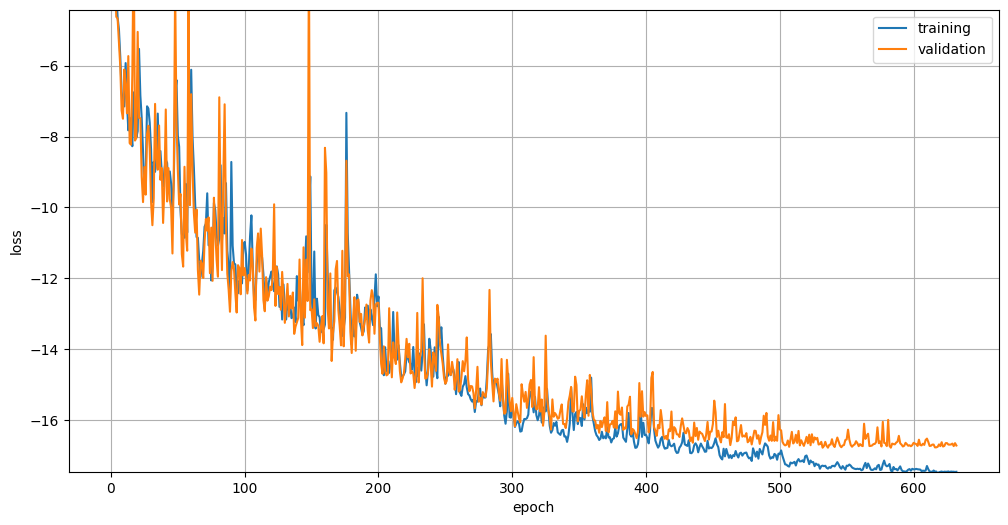

In [11]:
model.fit(
    x=grid_preds,
    theta=grid_cosmos,
    n_epochs=5000,
    # dataset
    batch_size=10000,
    vali_split=0.1,
    # optimizer
    learning_rate=1e-3,
    weight_decay=0.0,
    clip_by_global_norm=1.0,
    # schedule
    scheduler_kwargs={"factor": 0.75, "patience": 20, "cooldown": 10, "min_lr": 1e-6},
    # scheduler_kwargs={},
    # early stopping
    n_patience_epochs=100,
    min_delta=1e-5,
    save_model=True,
)

### convergence tests

24-02-13 04:36:15 likelihood_b INF   Drawing samples from the likelihood 
100%|████████████████████████████|   | 1/1 [00:00<00:00,  1.58it/s]           drawing samples with batch_size=10000
24-02-13 04:36:15 likelihood_b INF   Done drawing samples after 0:00:00.65 
100%|████████████████████████████|   | 2500/2500 [00:00<00:00, 8753.03it/s]   EECP: looping through cosmos
24-02-13 04:36:26 diagnostics. INF   TARP random reference points: Using the default 
100%|████████████████████████████|   | 48/48 [00:04<00:00, 10.81it/s]         TARP: looping through examples


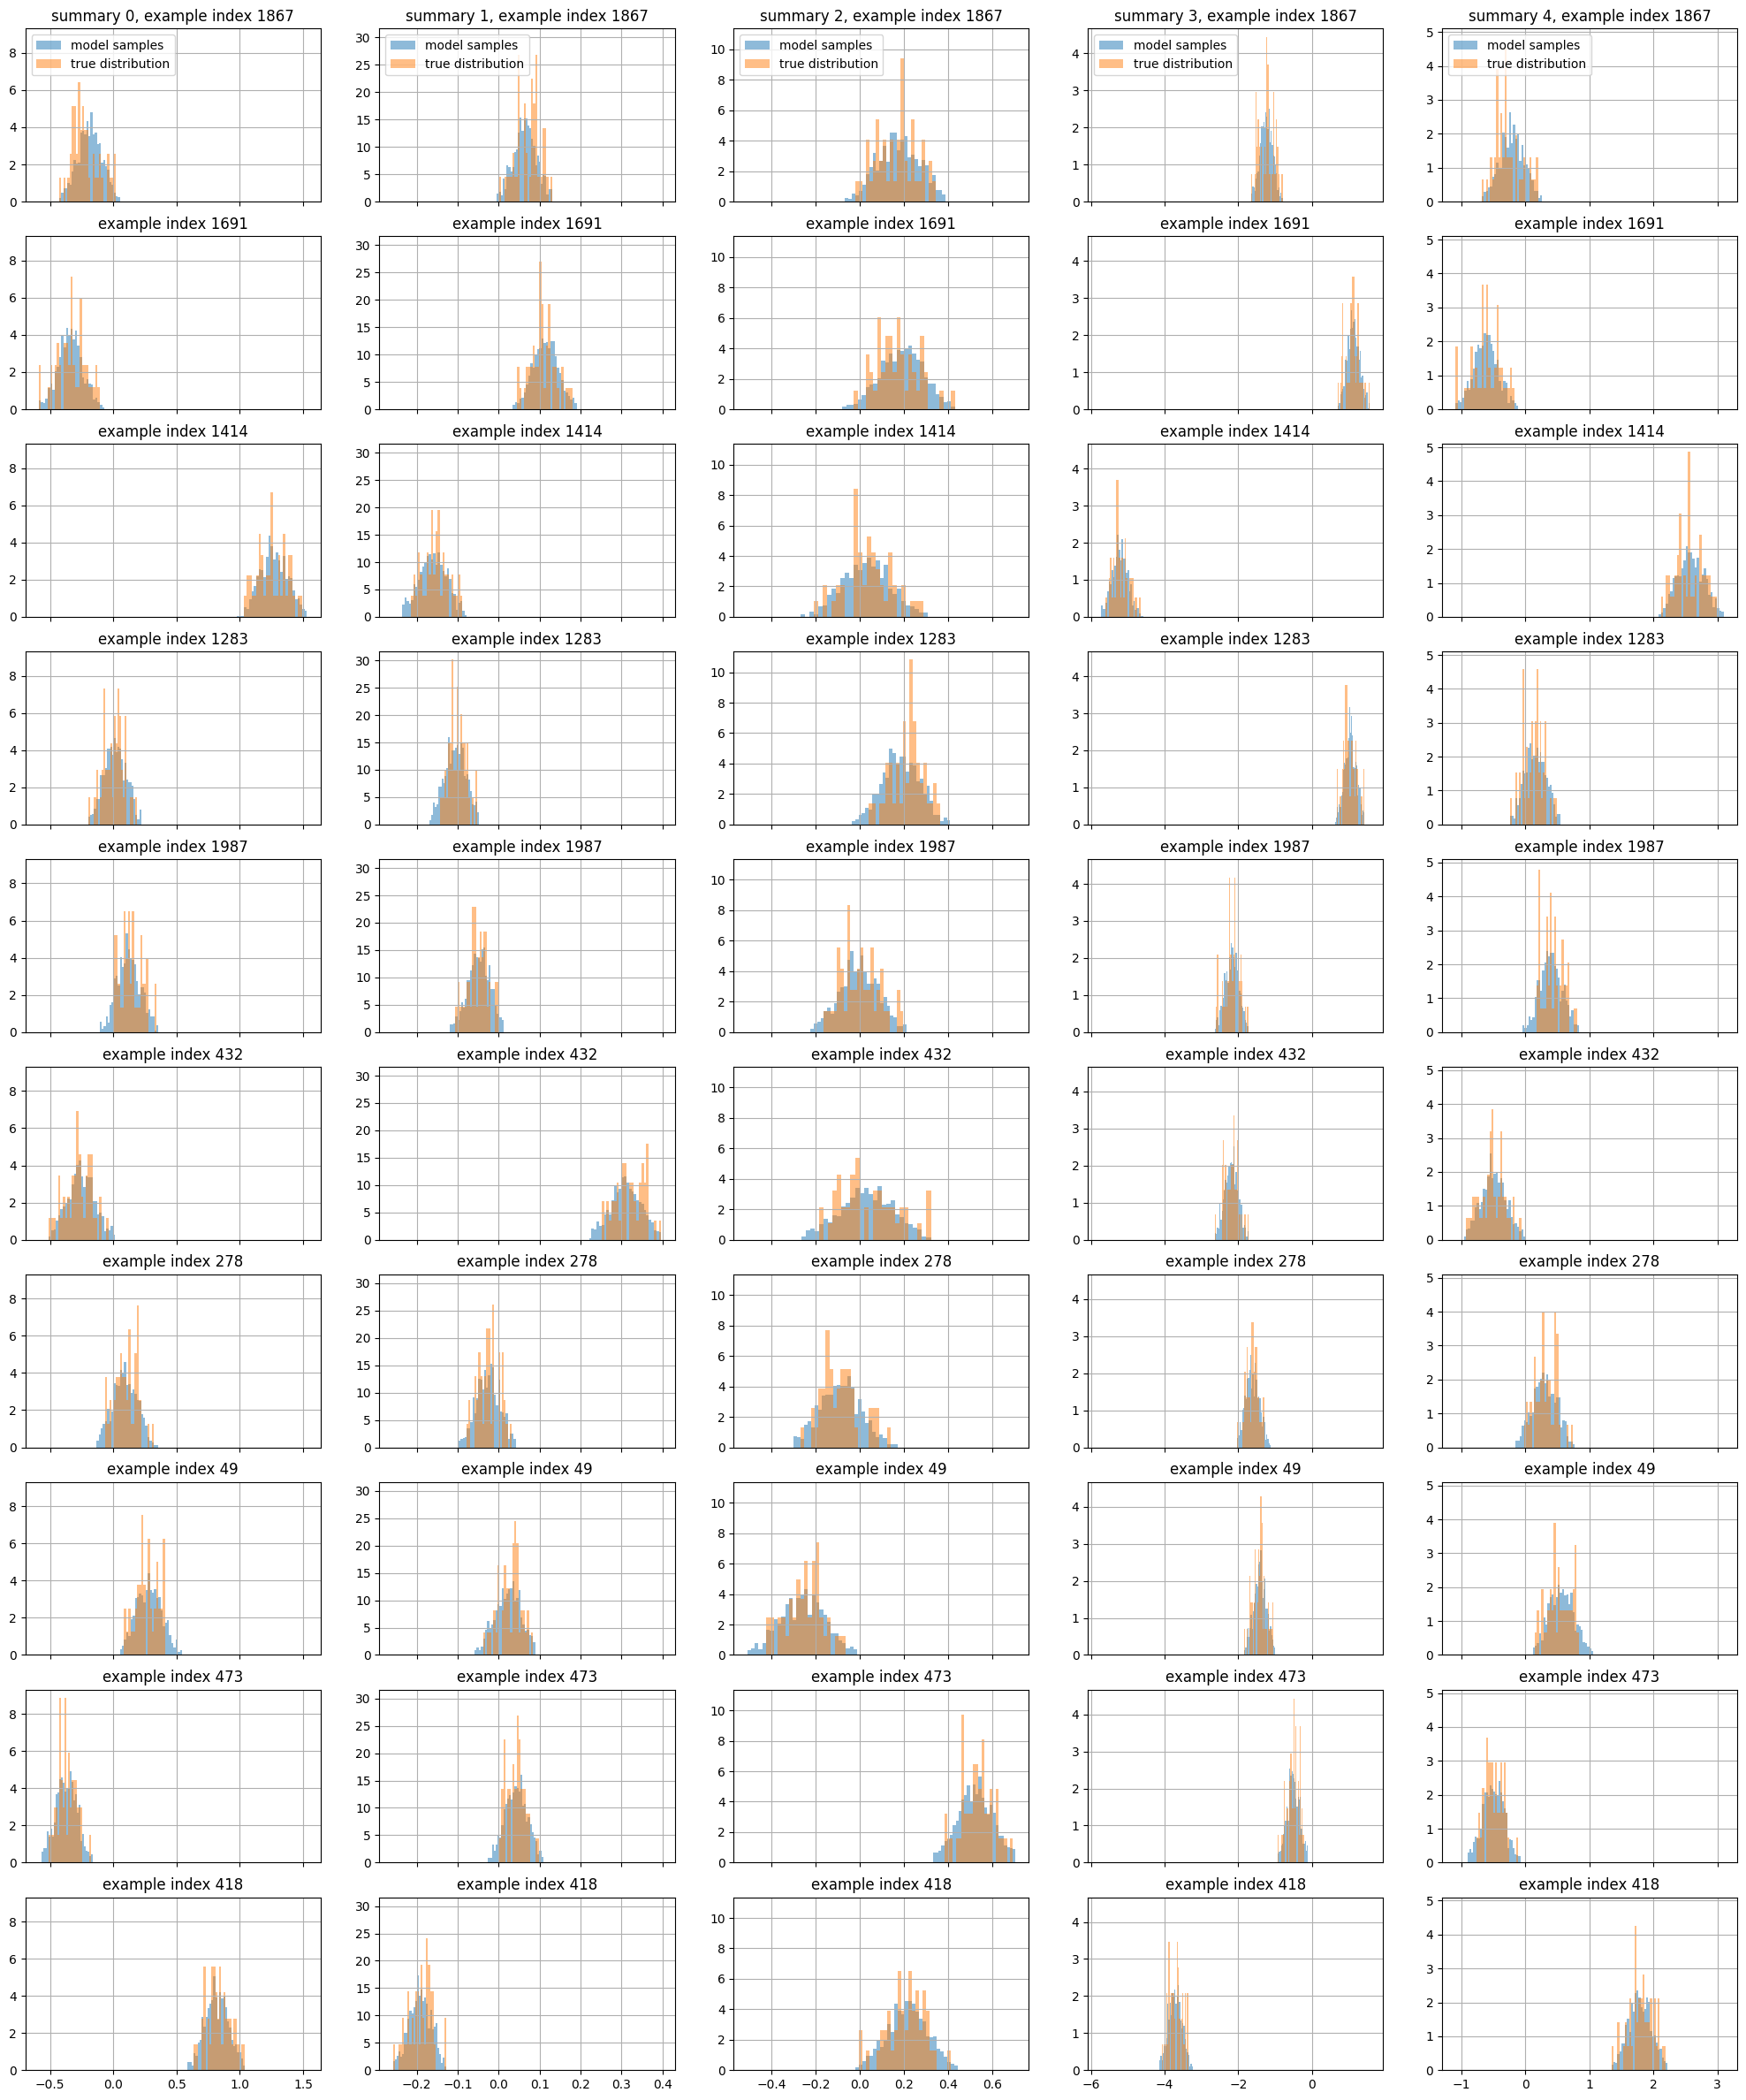

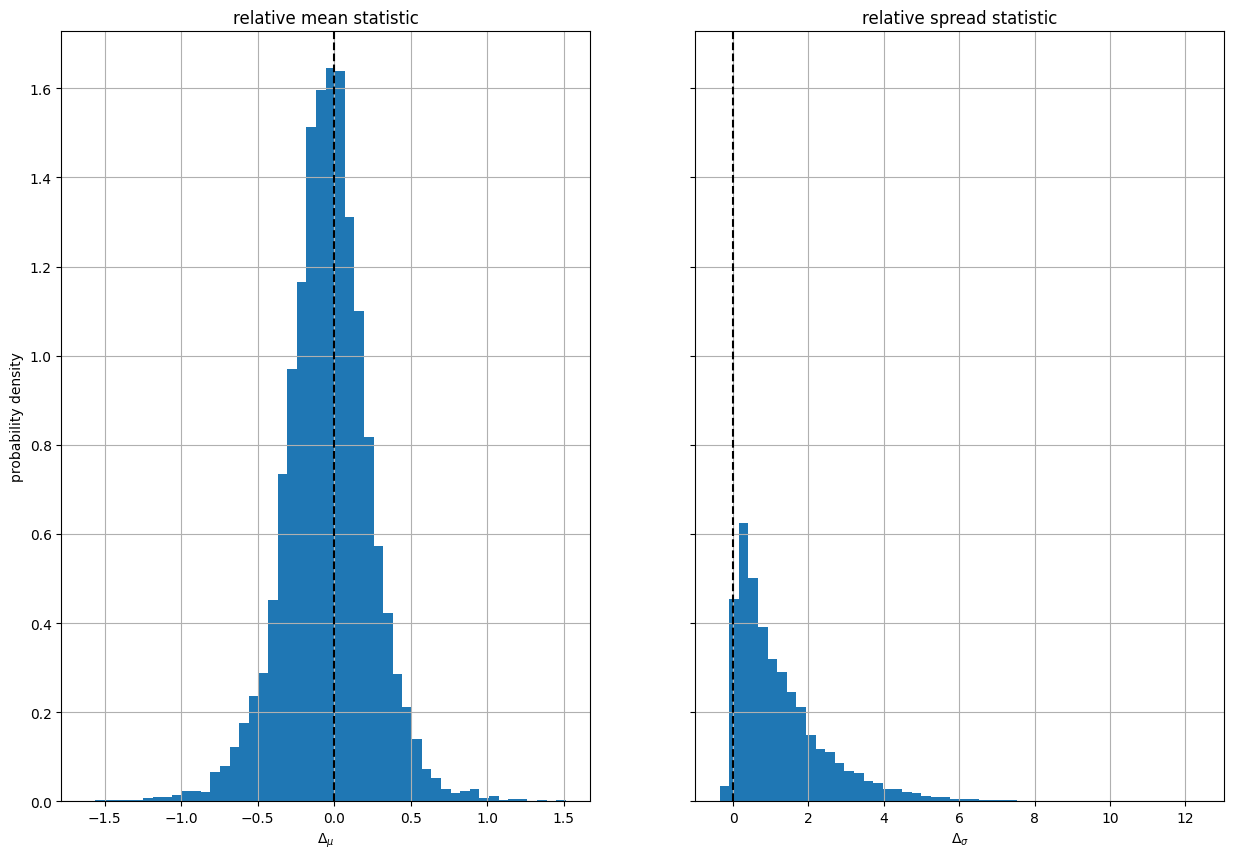

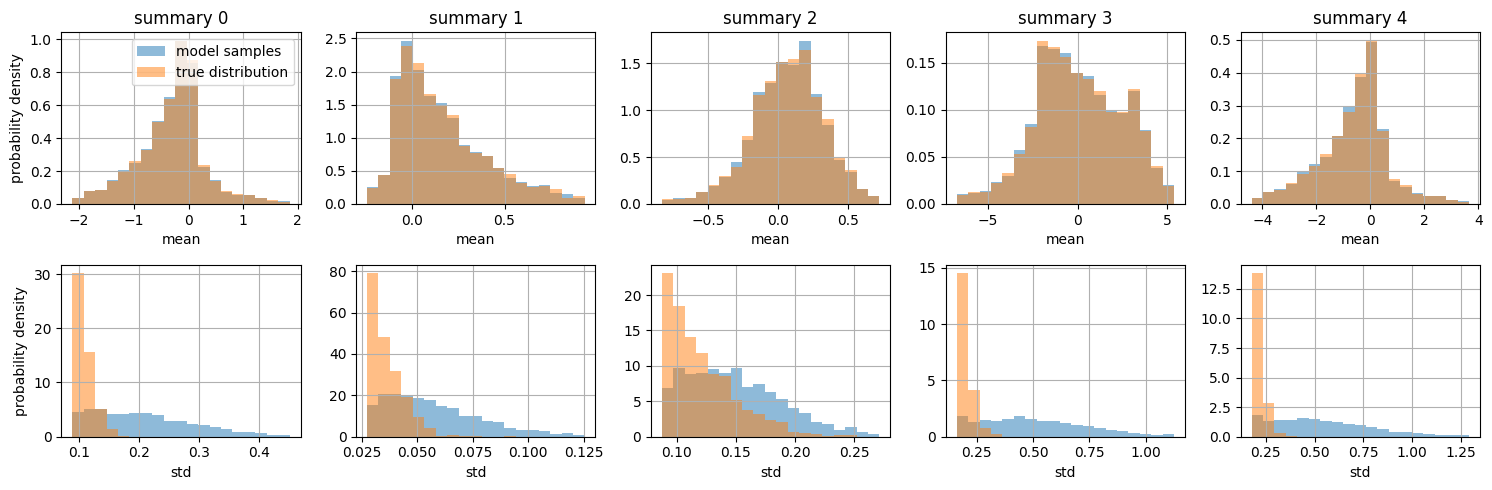

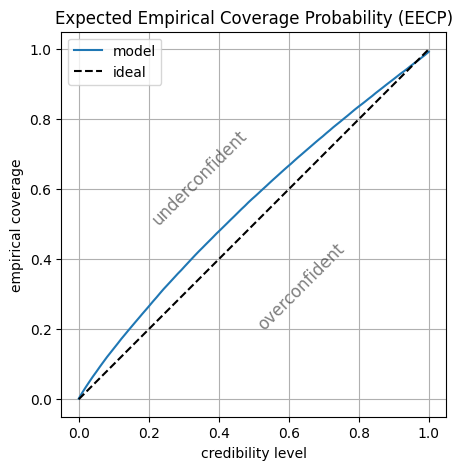

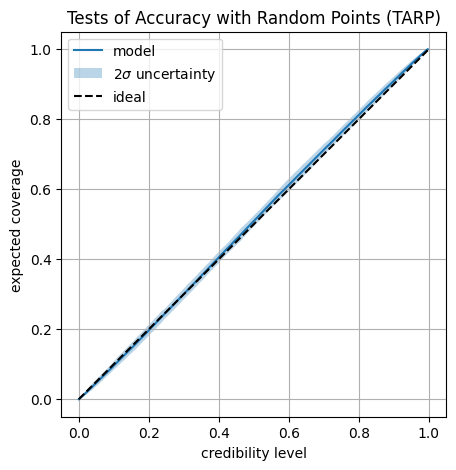

In [12]:
grid_preds_sample = model.plot_diagnostics(
    # these must be the raw arrays where the cosmo and example axis are still separate
    grid_preds_true=file_dict["grid/pred"][...,:len(params)], 
    grid_cosmos=file_dict["grid/cosmo"],
    n_samples=1000,
    do_hist=True,
    do_dlss=True,
    do_eecp=True,
    do_tarp=True,
)

### observation

In [19]:
i_obs = 0
# i_obs = np.argmin(np.sum(np.square(np.median(fidu_preds, axis=0, keepdims=True) - fidu_preds), axis=-1))

print(f"Using the example index {i_obs}")
# obs_pred = fidu_preds[i_obs]
obs_pred = file_dict["fiducial/vali/pred"][i_obs]

print(obs_pred)

Using the example index 0
[-0.29693127  0.1321996  -0.03293545  0.45800862 -0.5175502 ]


### MCMC

In [20]:
posterior_samples = model.sample_posterior(
    obs_pred,
)

24-02-13 04:38:32      mcmc.py INF   Initial values in prior: True 
24-02-13 04:38:32      mcmc.py INF   Starting the burn in MCMC chain (100 steps) 
24-02-13 04:38:43      mcmc.py INF   Starting the main MCMC chain (500 steps) 


100%|██████████| 500/500 [00:56<00:00,  8.81it/s]

24-02-13 04:39:40      mcmc.py INF   Saved the MCMC chain to /pscratch/sd/a/athomsen/run_files/v6/lensing_only/delta/2024-01-12_19-35-59_resnet_vanilla/290000_steps_new/likelihood_gmm/chain.npy 


### plotting

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

24-02-13 04:39:44  plotting.py INF   Saved the plot to /pscratch/sd/a/athomsen/run_files/v6/lensing_only/delta/2024-01-12_19-35-59_resnet_vanilla/290000_steps_new/likelihood_gmm/contours.png 


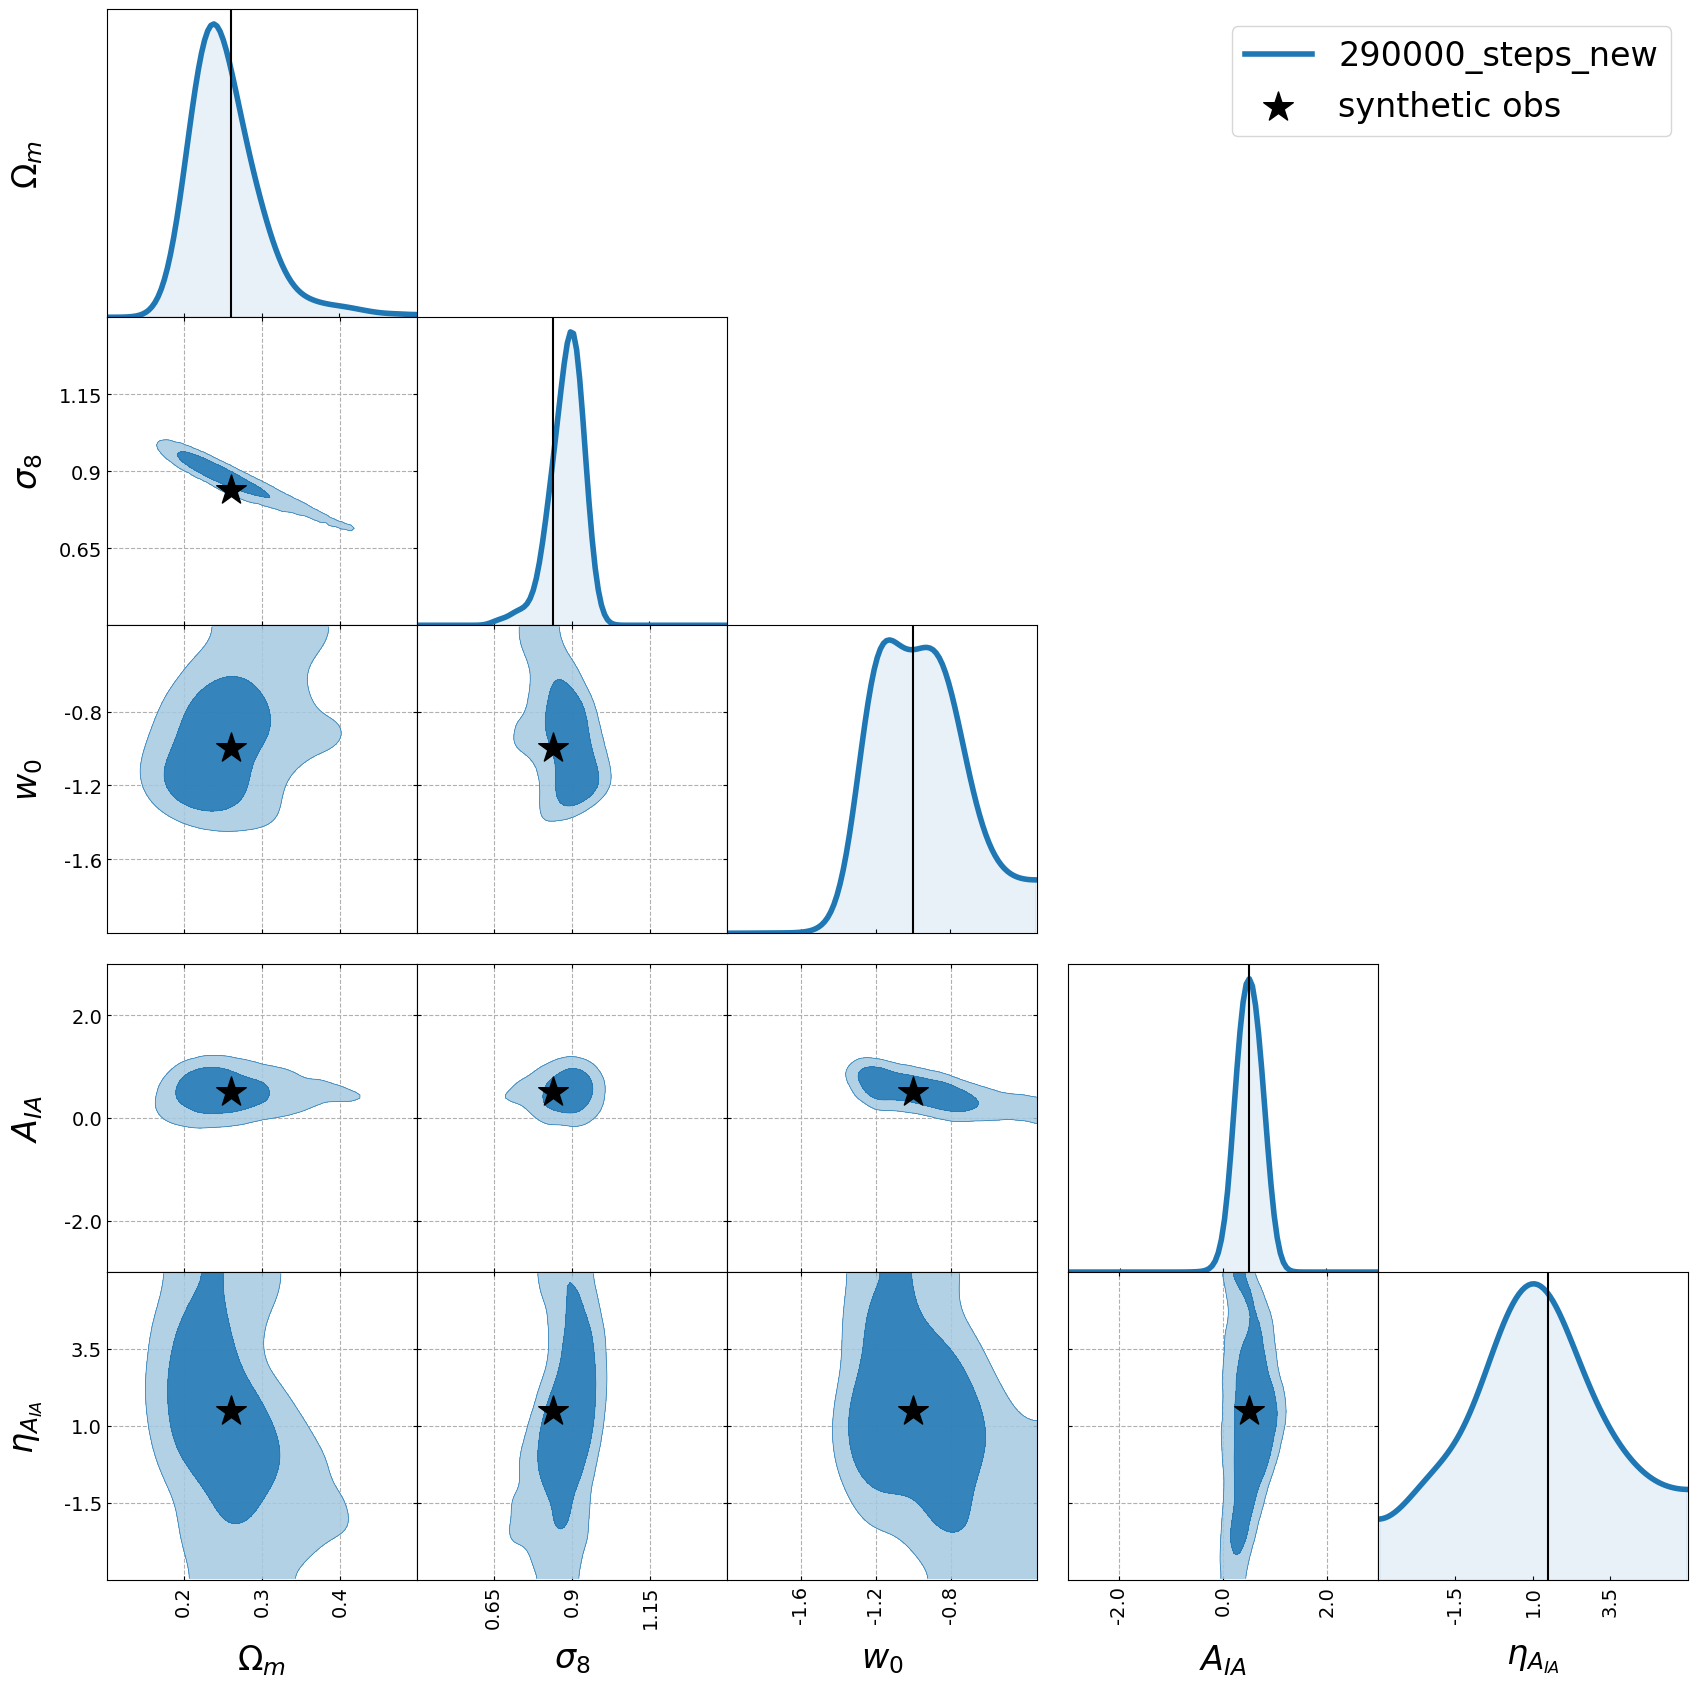

In [21]:
model.plot_contours(
    posterior_samples,
)